In [1]:
import sys
#!{sys.executable} -m pip install spacy


In [2]:
import nltk
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path
from tqdm import tqdm
import contractions
from nltk import pos_tag
from nltk.corpus import stopwords
import ast
import matplotlib.ticker as ticker

In [3]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
# Initialize stemmer/lemmatizer (run once)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [4]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\alvar\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

In [6]:
def get_vader_scores(sent_list, sentiment):
    if not isinstance(sent_list, list):
        return []
    return [sia.polarity_scores(sentence)[sentiment] for sentence in sent_list if isinstance(sentence, str)]

In [12]:
def clean_and_lowercase_list_column(df, column_name):
    """
    Converts stringified lists in a column to real lists and lowercases each string element.
    
    Parameters:
        df (pd.DataFrame): The DataFrame containing the column.
        column_name (str): The name of the column to clean.
    
    Returns:
        pd.DataFrame: A copy of the DataFrame with the cleaned column.
    """
    # df = df.copy()
    
    # Convert stringified lists to real lists
    df[column_name] = df[column_name].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else x
    )
    
    # Lowercase each string in the list
    df[column_name] = df[column_name].apply(
        lambda lst: [s.lower() for s in lst] if isinstance(lst, list) else lst
    )
    
    return df


In [7]:
from scipy.stats import sem, t
import numpy as np

def compute_ci(series, confidence=0.95):
    series = series.dropna()
    n = len(series)
    if n < 2:
        return (np.nan, np.nan, np.nan)
    m = series.mean()
    se = sem(series)
    h = se * t.ppf((1 + confidence) / 2., n - 1)
    return (m, m - h, m + h)


In [ ]:
def get_ci_and_average(df, column_name, sentiments=['neg', 'neu', 'pos', 'compound']):

    full_df = df.copy()

    results = {}  # store each income level's dataframe

    for i in range(1, 5):
        print(i)
        final_df = pd.DataFrame()
        print(f" ------------------------------Income {i} ------------------------------")
        df_i = full_df[full_df['Income Level'] == i].copy()

        print(len(df_i))
        for j in sentiments:
            df_i[f'vader_col_{j}'] = df_i[column_name].apply(get_vader_scores, sentiment = j)

            df_i[f'vader_avg_{j}'] = df_i[f'vader_col_{j}'].apply(lambda scores: sum(scores)/len(scores) if scores else None)
            # I am a bit lost in this mext step, what is country_year_avg calculatin exactly the average of a sentiment score across years for all the countries?
            country_year_avg = df_i.groupby(['Year', 'ISO-Code'])[f'vader_avg_{j}'].mean().reset_index()

            if j == sentiments[0]:
                country_counts = country_year_avg.groupby('Year')['ISO-Code'].nunique().rename(f'n_countries_{i}')
                final_df = pd.DataFrame(country_counts)

            # country_counts = country_year_avg.groupby('Year')['ISO-Code'].nunique()
            # Compute mean + 95% CI for each year
            ci_df = country_year_avg.groupby('Year')[f'vader_avg_{j}'].apply(compute_ci).apply(pd.Series)
            ci_df.columns = [f'mean_{j}_{i}', f'lower_{j}_{i}', f'upper_{j}_{i}']

            # Join to final_df
            if final_df.empty:
                final_df = ci_df.copy()
            else:
                final_df = final_df.join(ci_df, how='outer')  # join on Year index

        results[i] = final_df.reset_index()  # store result for each income level

    return results

In [8]:
base_path_alvaro = Path(r"C:\Users\alvar\OneDrive\Escritorio\BDS\Block_5\NLP\Project")

base_path = base_path_alvaro # change according to user

# EXTENDED SENTENCES

In [11]:
def extract_climate_sentences_with_context(speech, keywords):
    """
    Extracts sentences containing climate keywords along with one sentence before and after each.
    Returns a list of context windows (strings of 1–3 sentences).
    """
    doc = list(nlp(speech).sents)  # Convert to list to access by index
    context_windows = []

    for i, sent in enumerate(doc):
        sent_text = sent.text.strip()

        if any(kw.lower() in sent_text.lower() for kw in keywords):
            # Grab the previous, current, and next sentence if available
            prev_sent = doc[i-1].text.strip() if i > 0 else ''
            next_sent = doc[i+1].text.strip() if i < len(doc) - 1 else ''
            
            context = ' '.join([s for s in [prev_sent, sent_text, next_sent] if s])
            context_windows.append(context)

    return context_windows


#df_sentiment_1 = df_sentiment.copy() 

#df_sentiment_1['climate_sentences_extended'] = df_sentiment_1.progress_apply(
#    lambda row: extract_climate_sentences_with_context(row['speeches_for_keyword_search'], row['matched_climate_keywords']),
#    axis=1
#)


In [ ]:
#df_sentiment_1.to_csv(base_path_alvaro / "Final_df_extended.csv", index=False, encoding='utf-8')

## SENTIMENT ANALYSIS

In [9]:
final_df = pd.read_csv(base_path / "Final_df_extended.csv")
df_sentiment = final_df[final_df['contains_climate_keyword'] != False]
df_sentiment

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_postagging_expanded,speeches_for_keyword_search,matched_climate_keywords,contains_climate_keyword,climate_sentences,climate_sentences_extended
0,45,1990,ATG,"﻿Please accept my country's congratulations, S...",115,3134,3,please accept country congratulation sir unani...,please accept my country's congratulations sir...,['global warming'],True,['our oceans are polluted by various contamina...,"[""rain forests the most valuable of mankind's ..."
1,45,1990,AUS,"﻿It is with great pleasure. Sir, that I congra...",162,5289,4,great pleasure sir congratulate election presi...,it is with great pleasure. sir that i congratu...,['global environment'],True,['in areas such as threats to the global envir...,['in addition to the abiding issues of securit...
2,45,1990,AUT,"﻿\n\nI am pleased, Sir, to congratulate you on...",162,4743,4,pleased sir congratulate election presidency g...,i am pleased sir to congratulate you on your e...,"['carbon dioxide', 'emissions', 'global enviro...",True,['one of the most urgent priority measures one...,['studies undertaken at the vienna-based inter...
3,45,1990,BFA,"﻿\nMr. President, events in Eastern and Centra...",91,2948,1,president event eastern central europe gratify...,mr. president events in eastern and central eu...,"['carbon dioxide', 'greenhouse effect', 'ozone...",True,['we must urgently orient research towards tec...,['the same applies to the survival of our plan...
4,45,1990,BGD,"﻿\nMr. President, warm felicitations are due y...",180,3107,1,president warm felicitation due welldeserved e...,mr. president warm felicitations are due you o...,['climate change'],True,['we hope the proposed conventions on climate ...,['the conference must produce results that wil...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,79,2024,WSM,"Excellencies, \nI extend my congratulations t...",68,1572,2,excellency extend congratulation excellency ph...,excellencies i extend my congratulations to hi...,"['climate change', 'climate action', 'temperat...",True,['the effects of climate change are being live...,['please be assured of samoas support in the s...
3376,79,2024,YEM,"Your Majesties, Excellencies, and Highnesses, ...",57,1876,1,lady gentleman happy coincidence address today...,ladies and gentlemen it is a happy coincidence...,['climate change'],True,['this includes not only immediate humanitaria...,['for this reason the republic of yemen renews...
3377,79,2024,ZAF,President of the 79th Session of the UN Genera...,100,1870,3,president session general assembly philemon ya...,president of the 79th session of the un genera...,"['climate change', 'climate action', 'emission...",True,['as signatory to the paris agreement we are c...,['a few days ago south africa also endorsed th...
3378,79,2024,ZMB,"\n YOUR EXCELLENCY PHILEMON YANG, PRESIDENT O...",81,2348,2,lady gentleman congratulate excellency assumpt...,ladies and gentlemen i congratulate you your e...,"['climate change', 'extreme weather', 'climate...",True,['mr. president climate change and extreme wea...,"[""furthermore zambia recognises the efforts of..."


In [13]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'climate_sentences_extended')
type(df_sentiment.iloc[0]['climate_sentences_extended'])

list

In [64]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiments(sent_list):
    if isinstance(sent_list, list):
        scores = [analyzer.polarity_scores(s) for s in sent_list if isinstance(s, str)]
        if not scores:
            return {'neg': None, 'neu': None, 'pos': None, 'compound': None}
        # Average each component
        avg_scores = {
            'neg': sum(s['neg'] for s in scores) / len(scores),
            'neu': sum(s['neu'] for s in scores) / len(scores),
            'pos': sum(s['pos'] for s in scores) / len(scores),
            'compound': sum(s['compound'] for s in scores) / len(scores)
        }
        return avg_scores
    else:
        return {'neg': None, 'neu': None, 'pos': None, 'compound': None}


# Apply VADER to climate-related extended sentences
vader_scores = df_sentiment['climate_sentences_extended'].apply(get_vader_sentiments)

# Convert to separate columns
vader_df = pd.json_normalize(vader_scores)
vader_scores = pd.concat([df_sentiment.reset_index(drop=True), vader_df], axis=1)

# Basic descriptive statistics per Income Level
group_stats = vader_scores.groupby('Income Level')[['neg', 'neu', 'pos', 'compound']].agg(['mean', 'std', 'min', 'max', 'sum'])
display(group_stats)

neg                                        neu            \
                  mean       std  min    max        sum      mean       std   
Income Level                                                                  
1             0.079916  0.054190  0.0  0.392  46.191411  0.780853  0.064324   
2             0.081041  0.055004  0.0  0.344  74.963248  0.780223  0.058204   
3             0.076872  0.052291  0.0  0.392  68.646689  0.784650  0.057782   
4             0.074703  0.055508  0.0  0.380  73.507315  0.779076  0.061822   

                                             pos                        \
                min    max         sum      mean       std  min    max   
Income Level                                                             
1             0.537  1.000  451.332898  0.139245  0.055780  0.0  0.328   
2             0.532  0.972  721.705947  0.138722  0.050014  0.0  0.311   
3             0.500  0.954  700.692504  0.138476  0.052470  0.0  0.386   
4             0.497  0.963  766.611069  0.146211  0.054323  0.0  0.382   

                          compound                                        
                     sum      mean       std     min     max         sum  
Income Level                                                              
1              80.483492  0.299070  0.547613 -0.9853  0.9888  172.862189  
2             128.317509  0.323340  0.508091 -0.9859  0.9861  299.089362  
3             123.659437  0.307812  0.506132 -0.9927  0.9926  274.875954  
4             143.871224  0.352369  0.485373 -0.9821  0.9906  346.731324

In [71]:
# Add number of speeches per income group
entry_counts = vader_scores.groupby('Income Level').size()

# Recalculate normalized sum (average sum per speech)
normalized_sums = group_stats.loc[:, (slice(None), 'sum')].div(entry_counts, axis=0)

# Rename columns to reflect normalization
normalized_sums.columns = [f"{col}_norm" for col in normalized_sums.columns.get_level_values(0)]

# Concatenate with original group_stats
group_stats_adjusted = pd.concat([group_stats, normalized_sums], axis=1)

# Display the updated DataFrame
display(normalized_sums)

,neg_norm,neu_norm,pos_norm,compound_norm
Income Level,,,,
1,0.079916,0.780853,0.139245,0.299070
2,0.081041,0.780223,0.138722,0.323340
3,0.076872,0.784650,0.138476,0.307812
4,0.074703,0.779076,0.146211,0.352369


In [103]:
from scipy.stats import levene

levene_test = levene(
    vader_scores[vader_scores['Income Level'] == 1]['pos'].dropna(),
    vader_scores[vader_scores['Income Level'] == 2]['pos'].dropna(),
    vader_scores[vader_scores['Income Level'] == 3]['pos'].dropna(),
    vader_scores[vader_scores['Income Level'] == 4]['pos'].dropna()
)

print(levene_test)


LeveneResult(statistic=2.7981129630206056, pvalue=0.03868744331176525)


In [106]:
from pingouin import welch_anova

welch_result = welch_anova(
    data=vader_scores, 
    dv='pos',  # Dependent variable (use 'pos' if analyzing positivity)
    between='Income Level'  # Grouping variable
)

print(welch_result)

         Source  ddof1        ddof2         F     p-unc       np2
0  Income Level      3  1722.380279  4.516317  0.003671  0.004101


In [107]:
from pingouin import pairwise_gameshowell

posthoc = pairwise_gameshowell(
    data=final_df,
    dv='pos',
    between='Income Level'
)

print(posthoc)

   A  B   mean(A)   mean(B)      diff        se         T           df  \
0  1  2  0.137757  0.136033  0.001725  0.001932  0.892411  3495.831596   
1  1  3  0.137757  0.134447  0.003310  0.001958  1.690497  3625.210921   
2  1  4  0.137757  0.139186 -0.001429  0.001981 -0.721555  3768.179727   
3  2  3  0.136033  0.134447  0.001585  0.001517  1.045076  8510.479409   
4  2  4  0.136033  0.139186 -0.003154  0.001546 -2.039513  8744.794271   
5  3  4  0.134447  0.139186 -0.004739  0.001578 -3.003129  8633.457987   

       pval    hedges  
0  0.808812  0.024815  
1  0.328798  0.046797  
2  0.888538 -0.019287  
3  0.722870  0.022624  
4  0.173605 -0.043470  
5  0.014254 -0.064535  


# All plots here 

In [109]:
all_income_df = get_ci_and_average(df_sentiment, 'climate_sentences_extended')

1
 ------------------------------Income 1 ------------------------------
578
2
 ------------------------------Income 2 ------------------------------
925
3
 ------------------------------Income 3 ------------------------------
893
4
 ------------------------------Income 4 ------------------------------
984


In [151]:
all_income_df[4]

,Year,n_countries_4,mean_neg_4,lower_neg_4,upper_neg_4,mean_neu_4,lower_neu_4,upper_neu_4,mean_pos_4,lower_pos_4,upper_pos_4,mean_compound_4,lower_compound_4,upper_compound_4
0,1990,14,0.082974,0.059870,0.106079,0.800304,0.769756,0.830852,0.116799,0.096743,0.136856,0.195161,-0.061625,0.451948
1,1991,14,0.038105,0.015414,0.060795,0.801888,0.763983,0.839793,0.160055,0.126914,0.193196,0.653904,0.486010,0.821797
2,1992,10,0.060000,0.006894,0.113106,0.800300,0.750577,0.850023,0.139600,0.091638,0.187562,0.429260,-0.088548,0.947068
3,1993,6,0.063889,0.003051,0.124727,0.819417,0.761954,0.876880,0.116694,0.095146,0.138243,0.349300,-0.188312,0.886912
4,1994,3,0.083000,0.034068,0.131932,0.856333,0.743303,0.969364,0.061333,-0.005616,0.128282,-0.451567,-0.667627,-0.235507
5,1995,8,0.084542,0.020374,0.148710,0.758000,0.689362,0.826638,0.157625,0.106439,0.208811,0.362258,-0.146528,0.871045
6,1996,11,0.030682,0.011239,0.050125,0.788955,0.749495,0.828414,0.180364,0.134633,0.226094,0.704380,0.535827,0.872932
7,1997,9,0.051852,0.019565,0.084139,0.804009,0.742328,0.865691,0.144083,0.088118,0.200049,0.426061,0.063761,0.788361
8,1998,8,0.032438,-0.005461,0.070336,0.797175,0.730866,0.863484,0.170563,0.119317,0.221808,0.682820,0.508761,0.856879
9,1999,9,0.090435,0.027937,0.152933,0.769296,0.714410,0.824182,0.140102,0.104512,0.175692,0.301505,-0.228000,0.831009


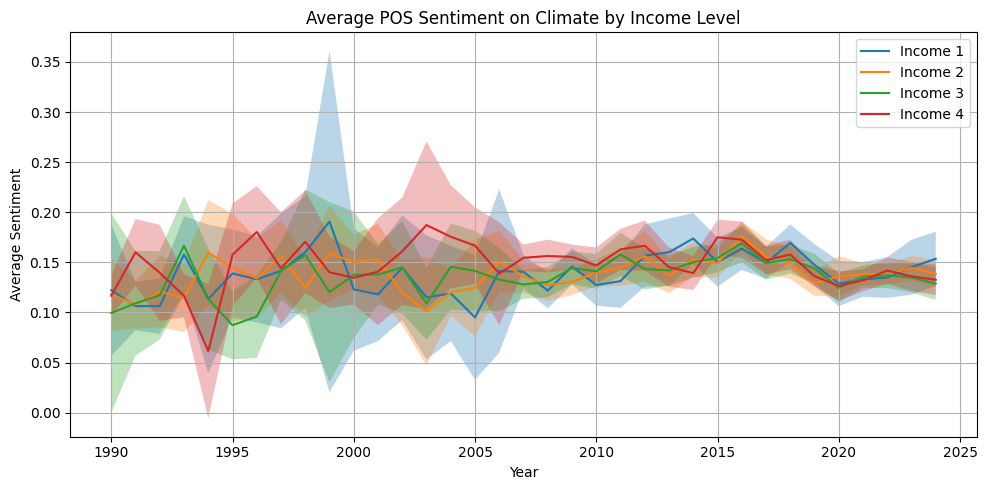

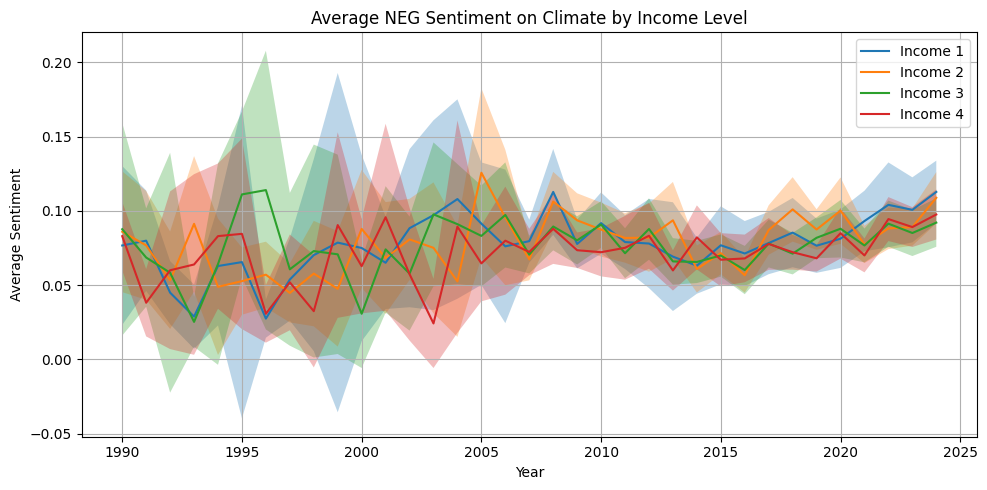

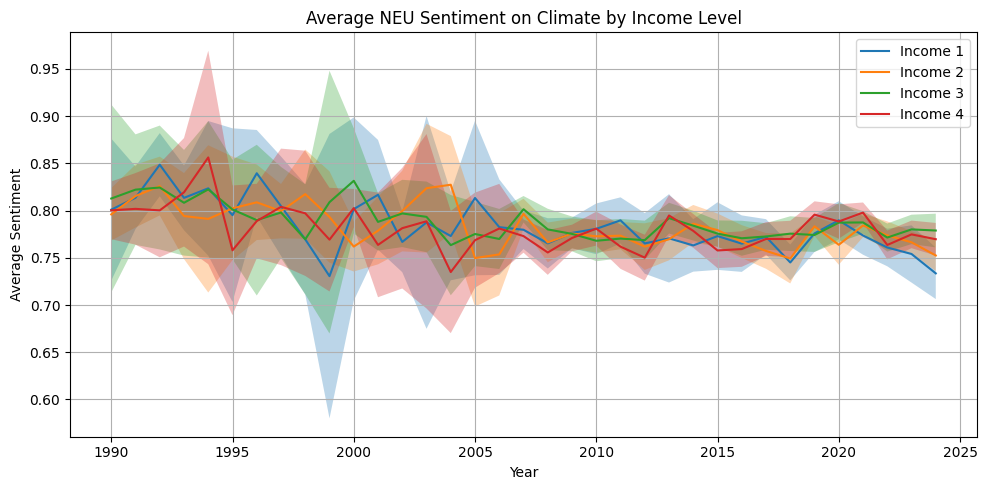

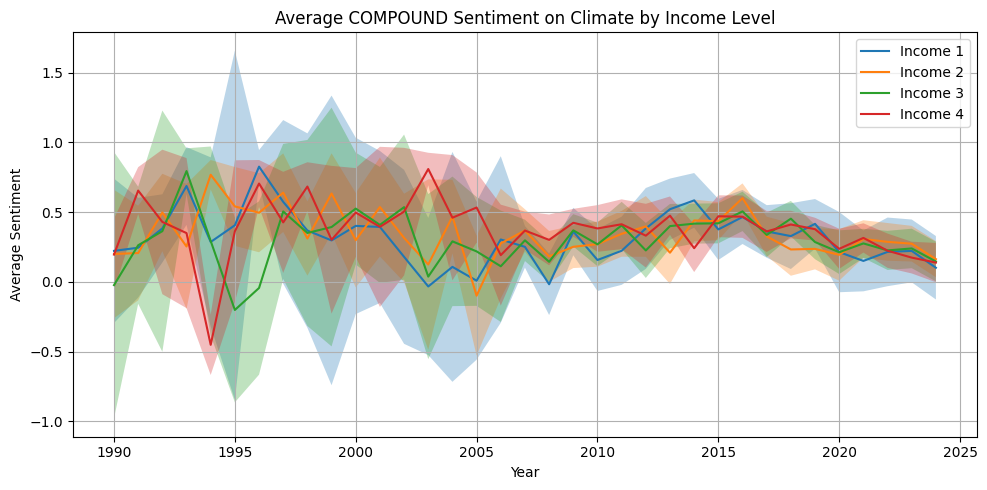

In [224]:
for sentiment in ['pos', 'neg', 'neu', 'compound']:
    plt.figure(figsize=(10, 5))
    for inc in range(1, 5):
        df_plot = all_income_df[inc]
        sns.lineplot(x='Year', y=f'mean_{sentiment}_{inc}', data=df_plot, label=f'Income {inc}')
        plt.fill_between(
            df_plot['Year'],
            df_plot[f'lower_{sentiment}_{inc}'],
            df_plot[f'upper_{sentiment}_{inc}'],
            alpha=0.3
        )
    plt.title(f'Average {sentiment.upper()} Sentiment on Climate by Income Level')
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path = Path(base_path) / "NLP_BDS" / f"avg_{sentiment.upper()}_by_income_level_EXTENDED_SENTENCES.png"
    plt.savefig(plot_path)

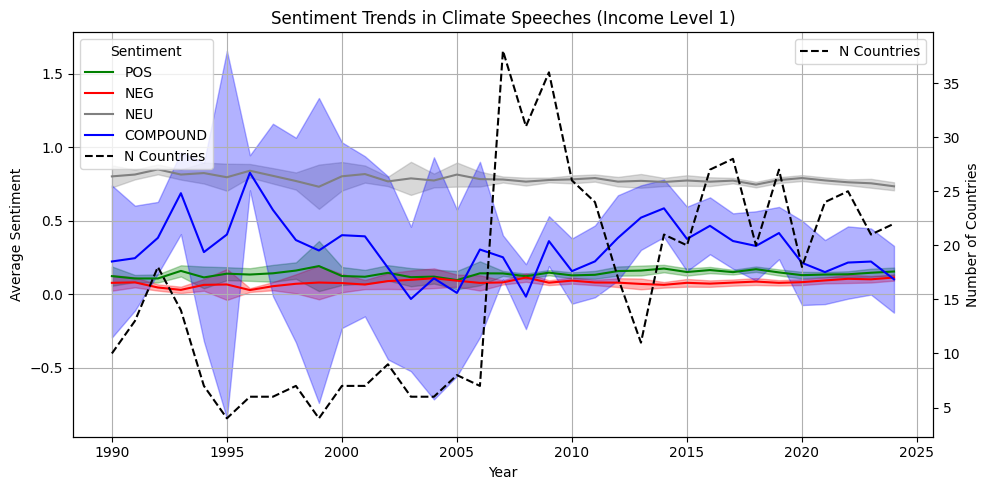

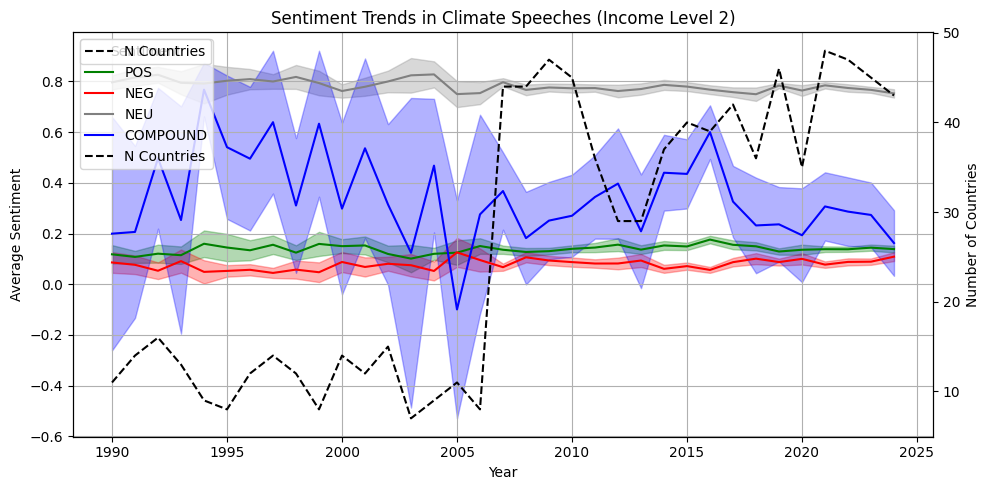

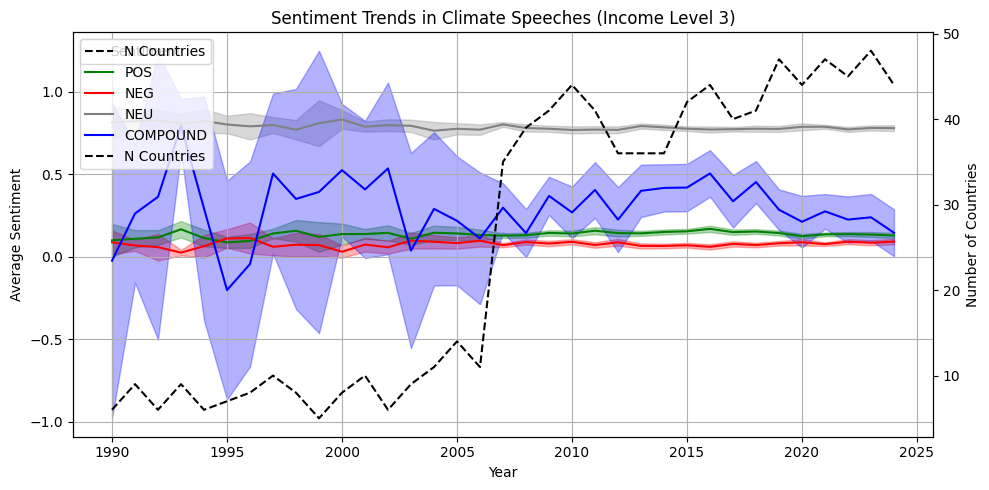

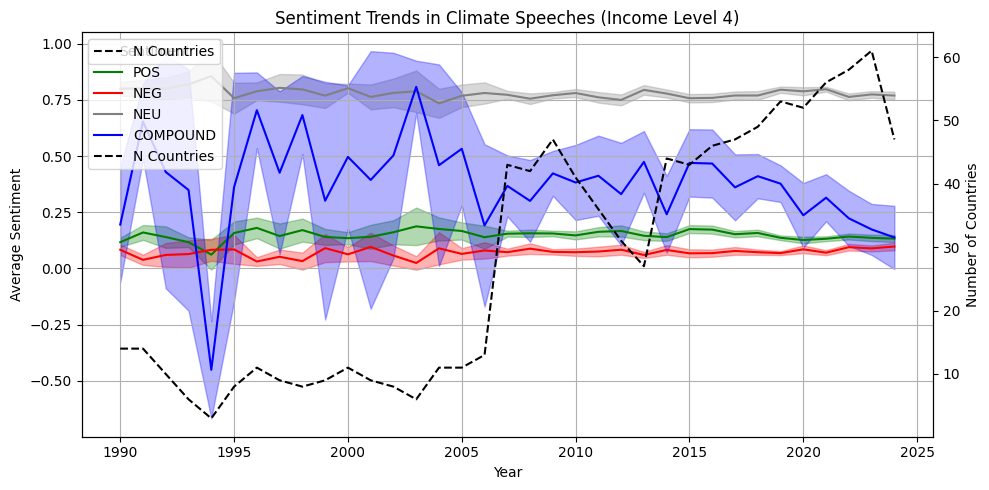

In [225]:
sentiments = ['pos', 'neg', 'neu', 'compound']
colors = {
    'pos': 'green',
    'neg': 'red',
    'neu': 'gray',
    'compound': 'blue'
}

for inc in range(1, 5):
    df_plot = all_income_df[inc]

    fig, ax1 = plt.subplots(figsize=(10, 5))  # ⬅️ create figure and main axis (sentiment)
    
    for s in sentiments:
        mean_col = f'mean_{s}_{inc}'
        lower_col = f'lower_{s}_{inc}'
        upper_col = f'upper_{s}_{inc}'

        sns.lineplot(
            x='Year', y=mean_col, data=df_plot, label=s.upper(), color=colors[s], ax=ax1
        )
        ax1.fill_between(
            df_plot['Year'],
            df_plot[lower_col],
            df_plot[upper_col],
            color=colors[s],
            alpha=0.3
        )

    # ➕ Secondary axis for number of countries
    ax2 = ax1.twinx()
    sns.lineplot(
        x='Year',
        y=f'n_countries_{inc}',
        data=df_plot,
        color='black',
        linestyle='--',
        linewidth=1.5,
        ax=ax2,
        label='N Countries'
    )
    ax2.set_ylabel('Number of Countries')

    # ✅ Titles, legends, save
    ax1.set_title(f'Sentiment Trends in Climate Speeches (Income Level {inc})')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Sentiment')
    ax1.grid(True)

    # Handle both legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', title='Sentiment')

    plt.tight_layout()
    plot_path = Path(base_path) / "NLP_BDS" / f"avg_sentiments_income_level_{inc}_EXTENDED_SENTENCES.png"
    plt.savefig(plot_path)
    #plt.show()


## Compute weighted values by number of countries

In [16]:
def get_weighted_vader_average(sent_list, sentiment):
    if not isinstance(sent_list, list):
        return None
    valid_sents = [s for s in sent_list if isinstance(s, str)]
    scores = [sia.polarity_scores(sentence)[sentiment] for sentence in valid_sents]
    weights = [len(sentence.split()) for sentence in valid_sents]
    if not scores or not weights:
        return None
    return np.average(scores, weights=weights)


In [17]:
def get_ci_and_average_acc_length(df, column_name, sentiments=['neg', 'neu', 'pos', 'compound']):

    full_df = df.copy()

    results = {}  # store each income level's dataframe

    for i in range(1, 5):
        print(i)
        final_df = pd.DataFrame()
        print(f" ------------------------------Income {i} ------------------------------")
        df_i = full_df[full_df['Income Level'] == i].copy()

        print(len(df_i))
        for j in sentiments:
            #df_i[f'vader_col_{j}'] = df_i[column_name].apply(get_vader_scores, sentiment = j)

            df_i[f'vader_avg_{j}'] = df_i[column_name].apply(get_weighted_vader_average, sentiment=j)


            # I am a bit lost in this mext step, what is country_year_avg calculatin exactly the average of a sentiment score across years for all the countries?
            country_year_avg = df_i.groupby(['Year', 'ISO-Code'])[f'vader_avg_{j}'].mean().reset_index()

            if j == sentiments[0]:
                country_counts = country_year_avg.groupby('Year')['ISO-Code'].nunique().rename(f'n_countries_{i}')
                final_df = pd.DataFrame(country_counts)

            # country_counts = country_year_avg.groupby('Year')['ISO-Code'].nunique()
            # Compute mean + 95% CI for each year
            ci_df = country_year_avg.groupby('Year')[f'vader_avg_{j}'].apply(compute_ci).apply(pd.Series)
            ci_df.columns = [f'mean_{j}_{i}', f'lower_{j}_{i}', f'upper_{j}_{i}']

            # Join to final_df
            if final_df.empty:
                final_df = ci_df.copy()
            else:
                final_df = final_df.join(ci_df, how='outer')  # join on Year index

        results[i] = final_df.reset_index()  # store result for each income level

    return results

In [18]:
all_income_df_acc_lentgh = get_ci_and_average_acc_length(df_sentiment, 'climate_sentences_extended')
all_income_df_acc_lentgh

1
 ------------------------------Income 1 ------------------------------
578
2
 ------------------------------Income 2 ------------------------------
925
3
 ------------------------------Income 3 ------------------------------
893
4
 ------------------------------Income 4 ------------------------------
984


{1:     Year  n_countries_1  mean_neg_1  lower_neg_1  upper_neg_1  mean_neu_1  \
 0   1990             10    0.075761     0.021805     0.129717    0.804066   
 1   1991             13    0.079060     0.045089     0.113030    0.814514   
 2   1992             18    0.046232     0.024144     0.068321    0.846702   
 3   1993             14    0.028441     0.006767     0.050116    0.812760   
 4   1994              7    0.063010     0.022782     0.103237    0.825020   
 5   1995              4    0.065500    -0.039766     0.170766    0.795250   
 6   1996              6    0.027259     0.014752     0.039767    0.839599   
 7   1997              6    0.054930     0.027885     0.081976    0.803839   
 8   1998              7    0.069776     0.004811     0.134741    0.769278   
 9   1999              4    0.078153    -0.036030     0.192336    0.731919   
 10  2000              7    0.074994     0.012214     0.137775    0.801598   
 11  2001              7    0.064554     0.033679     0.09542

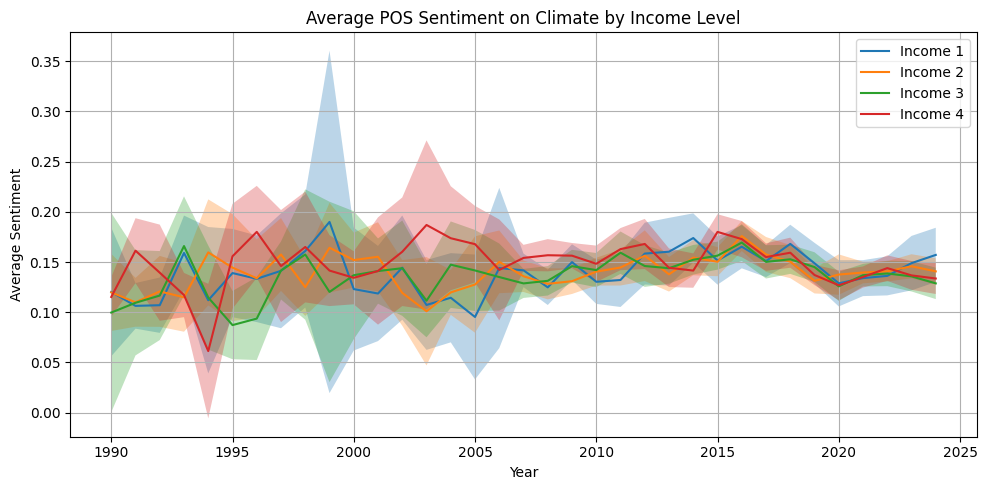

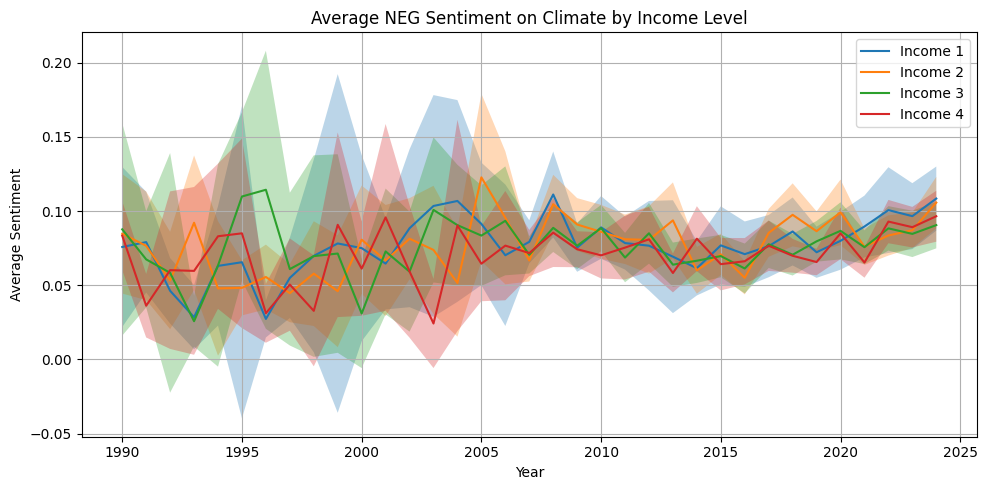

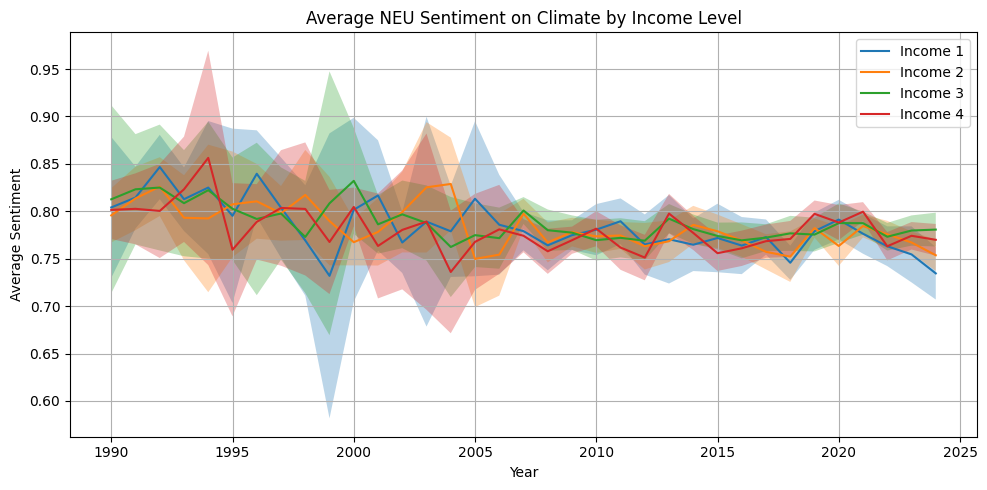

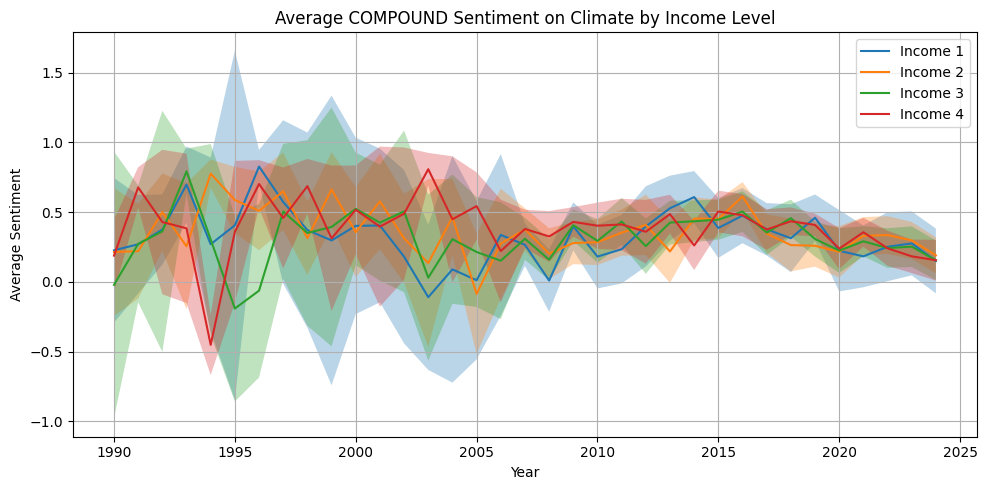

In [21]:
for sentiment in ['pos', 'neg', 'neu', 'compound']:
    plt.figure(figsize=(10, 5))
    for inc in range(1, 5):
        df_plot = all_income_df_acc_lentgh[inc]
        sns.lineplot(x='Year', y=f'mean_{sentiment}_{inc}', data=df_plot, label=f'Income {inc}')
        plt.fill_between(
            df_plot['Year'],
            df_plot[f'lower_{sentiment}_{inc}'],
            df_plot[f'upper_{sentiment}_{inc}'],
            alpha=0.3
        )
    plt.title(f'Average {sentiment.upper()} Sentiment on Climate by Income Level')
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plot_path = Path(base_path) / "NLP_BDS" / f"avg_{sentiment.upper()}_by_income_level_EXTENDED_SENTENCES.png"
    #plt.savefig(plot_path)

# Count the number of Positive and Negative Sentences per income group

In [33]:
final_df = pd.read_csv(base_path / "Final_df_extended.csv")
df_sentiment = final_df[final_df['contains_climate_keyword'] != False]
df_sentiment

,Session,Year,ISO-Code,Speech,number_sentences,number_tokens,Income Level,cleaned_speeches_postagging_expanded,speeches_for_keyword_search,matched_climate_keywords,contains_climate_keyword,climate_sentences,climate_sentences_extended
0,45,1990,ATG,"﻿Please accept my country's congratulations, S...",115,3134,3,please accept country congratulation sir unani...,please accept my country's congratulations sir...,['global warming'],True,['our oceans are polluted by various contamina...,"[""rain forests the most valuable of mankind's ..."
1,45,1990,AUS,"﻿It is with great pleasure. Sir, that I congra...",162,5289,4,great pleasure sir congratulate election presi...,it is with great pleasure. sir that i congratu...,['global environment'],True,['in areas such as threats to the global envir...,['in addition to the abiding issues of securit...
2,45,1990,AUT,"﻿\n\nI am pleased, Sir, to congratulate you on...",162,4743,4,pleased sir congratulate election presidency g...,i am pleased sir to congratulate you on your e...,"['carbon dioxide', 'emissions', 'global enviro...",True,['one of the most urgent priority measures one...,['studies undertaken at the vienna-based inter...
3,45,1990,BFA,"﻿\nMr. President, events in Eastern and Centra...",91,2948,1,president event eastern central europe gratify...,mr. president events in eastern and central eu...,"['carbon dioxide', 'greenhouse effect', 'ozone...",True,['we must urgently orient research towards tec...,['the same applies to the survival of our plan...
4,45,1990,BGD,"﻿\nMr. President, warm felicitations are due y...",180,3107,1,president warm felicitation due welldeserved e...,mr. president warm felicitations are due you o...,['climate change'],True,['we hope the proposed conventions on climate ...,['the conference must produce results that wil...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,79,2024,WSM,"Excellencies, \nI extend my congratulations t...",68,1572,2,excellency extend congratulation excellency ph...,excellencies i extend my congratulations to hi...,"['climate change', 'climate action', 'temperat...",True,['the effects of climate change are being live...,['please be assured of samoas support in the s...
3376,79,2024,YEM,"Your Majesties, Excellencies, and Highnesses, ...",57,1876,1,lady gentleman happy coincidence address today...,ladies and gentlemen it is a happy coincidence...,['climate change'],True,['this includes not only immediate humanitaria...,['for this reason the republic of yemen renews...
3377,79,2024,ZAF,President of the 79th Session of the UN Genera...,100,1870,3,president session general assembly philemon ya...,president of the 79th session of the un genera...,"['climate change', 'climate action', 'emission...",True,['as signatory to the paris agreement we are c...,['a few days ago south africa also endorsed th...
3378,79,2024,ZMB,"\n YOUR EXCELLENCY PHILEMON YANG, PRESIDENT O...",81,2348,2,lady gentleman congratulate excellency assumpt...,ladies and gentlemen i congratulate you your e...,"['climate change', 'extreme weather', 'climate...",True,['mr. president climate change and extreme wea...,"[""furthermore zambia recognises the efforts of..."


In [34]:
df_sentiment = clean_and_lowercase_list_column(df_sentiment, 'climate_sentences_extended')
type(df_sentiment.iloc[0]['climate_sentences_extended'])

list

## Regular Dictionary

In [35]:
import urllib.request

url = "https://gist.githubusercontent.com/bastings/d6f99dcb6c82231b94b013031356ba05/raw/f80a0281eba8621b122012c89c8b5e2200b39fd6/sent_lexicon"
output_file = "sent_lexicon"

urllib.request.urlretrieve(url, output_file)
print("Downloaded successfully.")


Downloaded successfully.


In [36]:
lexicon_dict = {}

with open("sent_lexicon", mode="r", encoding="utf-8") as f:
    for line in f:
        pairs = line.split()
        word = pairs[2].split('=')[1]
        pol = pairs[-1].split('=')[1]
        subtype = pairs[0].split('=')[1]

        # Convert string polarity to numeric value
        if pol == "positive":
            polarity = 1
        elif pol == "neutral":
            polarity = 0
        elif pol == "negative":
            polarity = -1
        else:
            polarity = 0  # fallback in case of unexpected value

        # Strengthen polarity if it's a strong subjectivity word
        if subtype == 'strongsubj':
            polarity *= 2

        lexicon_dict[word] = polarity

# Optional: check a few entries
print({k: lexicon_dict[k] for k in list(lexicon_dict)[:10]})


{'abandoned': -1, 'abandonment': -1, 'abandon': -1, 'abase': -2, 'abasement': -2, 'abash': -2, 'abate': -1, 'abdicate': -1, 'aberration': -2, 'abhor': -2}


In [30]:
df = df_sentiment[['climate_sentences_extended', 'Income Level']]

# Function to remove punctuation from a sentence
def clean_sent_list(sent_list):
    return [re.sub(r'[^\w\s]', '', sent) for sent in sent_list]

# Apply to your DataFrame column
df['climate_sentences_extended_no_punctuation'] = df['climate_sentences_extended'].apply(clean_sent_list)
df

C:\Users\alvar\AppData\Local\Temp\ipykernel_9068\1892929227.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['climate_sentences_extended_no_punctuation'] = df['climate_sentences_extended'].apply(clean_sent_list)


,climate_sentences_extended,Income Level,climate_sentences_extended_no_punctuation
0,[rain forests the most valuable of mankind's t...,3,[rain forests the most valuable of mankinds te...
1,[in addition to the abiding issues of security...,4,[in addition to the abiding issues of security...
2,[studies undertaken at the vienna-based intern...,4,[studies undertaken at the viennabased interna...
3,[the same applies to the survival of our plane...,1,[the same applies to the survival of our plane...
4,[the conference must produce results that will...,1,[the conference must produce results that will...
...,...,...,...
3375,[please be assured of samoas support in the su...,2,[please be assured of samoas support in the su...
3376,[for this reason the republic of yemen renews ...,1,[for this reason the republic of yemen renews ...
3377,[a few days ago south africa also endorsed the...,3,[a few days ago south africa also endorsed the...
3378,[furthermore zambia recognises the efforts of ...,2,[furthermore zambia recognises the efforts of ...


In [32]:
for i in range(1, 5):
    print('---------------------------- Income Level', i, "-------------------------------")
    groupped_df = df[df['Income Level'] == i]

    print("In this group there is a total of", len(groupped_df), "entries")

    positive = 0
    negative = 0
    neutral = 0
    base_threshold = 2

    for row_idx in range(len(groupped_df)):
        for sentence in groupped_df.iloc[row_idx]['climate_sentences_extended_no_punctuation']:
            tokens = sentence.split()
            len_sentence = len(tokens)
            token_scores = [lexicon_dict.get(token, 0) for token in tokens]
            score = sum(token_scores)

            if score > base_threshold:
                positive += 1
            elif score == base_threshold:
                neutral += 1
            else:
                negative += 1

    total = positive + negative + neutral
    print(f"There is a total of {positive} positive sentences out of {total}")
    print(f"There is a total of {negative} negative sentences out of {total}")
    print(f"There is a total of {neutral} neutral sentences out of {total}")


---------------------------- Income Level 1 -------------------------------
In this group there is a total of 578 entries
There is a total of 969 positive sentences out of 1870
There is a total of 767 negative sentences out of 1870
There is a total of 134 neutral sentences out of 1870
---------------------------- Income Level 2 -------------------------------
In this group there is a total of 925 entries
There is a total of 2302 positive sentences out of 4348
There is a total of 1706 negative sentences out of 4348
There is a total of 340 neutral sentences out of 4348
---------------------------- Income Level 3 -------------------------------
In this group there is a total of 893 entries
There is a total of 2255 positive sentences out of 4196
There is a total of 1599 negative sentences out of 4196
There is a total of 342 neutral sentences out of 4196
---------------------------- Income Level 4 -------------------------------
In this group there is a total of 984 entries
There is a total

## VADER

In [ ]:
def get_vader_scores_individually(sentence, sentiment):
    if not isinstance(sentence, str):
        return []
    return sia.polarity_scores(sentence)[sentiment]

In [54]:
results = []

# Loop through income groups 1 to 4
for i in range(1, 5):
    grouped_df = df_sentiment[df_sentiment['Income Level'] == i]

    positive = 0
    negative = 0
    neutral = 0
    base_threshold = 0.05  # Use standard VADER threshold

    for row in grouped_df.itertuples():
        for sentence in getattr(row, 'climate_sentences_extended'):
            tokens = sentence.split()
            if isinstance(sentence, str):
                score = get_vader_scores_individually(sentence, "compound")
                if score[0] > base_threshold:
                    positive += 1
                elif score[0] < -base_threshold:
                    negative += 1
                else:
                    neutral += 1

    total = positive + negative + neutral
    results.append({
        "Income Level": i,
        "Entries": total,
        "Positive": positive,
        "Negative": negative,
        "Neutral": neutral
    })

# Convert results to DataFrame
vader_sentiment_df = pd.DataFrame(results)
vader_sentiment_df

,Income Level,Entries,Positive,Negative,Neutral
0,1,1870,1235,600,35
1,2,4348,2944,1308,96
2,3,4196,2840,1273,83
3,4,4440,3065,1270,105
